# IEF_ALL Visualization

## 1. Configuration

You must guarantee that the values are correct in order to achieve desired results.

In [1]:
# The results directory as produced by IEF_ALL
RESULTS_DIR = "../../RESULTS/ALL"

## 1. Utilities

Most of the time, you don't need to tinker with this; just proceed to the next section.

### a) Loading results

In [2]:
from pathlib import Path
import msgpack
import msgpack_numpy
from pprint import pprint
msgpack_numpy.patch()

import numpy as np
import matplotlib.pyplot as plt

def load_results(results_dir):
    # type: (str) -> None
    INDEX_FILE_PATH = Path(results_dir) / "index.msgpack"
    with open(INDEX_FILE_PATH, 'rb') as index_file:
        results = msgpack.unpack(index_file, raw=False)
    return results


### b) Inferring model names from results

In [3]:
import re

def infer_model_name(model_type_name, checkpoint_path):
    # type: (str, str) -> str

    p = checkpoint_path.lower()

    # FFNN
    maTch = re.search(r'seed\d+[\\/]+epoch\_\d+', p)
    if maTch:
        return model_type_name + "::" + maTch.group(0)
    
    # LGBM
    maTch = re.search(r'(seed\d+)[\\/]+(.*)\.model', p)
    if maTch:
        # Default LGBM model checkpoint path:
        # .../seed<N>/lightgbm.model where N is an integer
        # so we could omit the "lightgbm.model" part
        if maTch.group(2) == "lightgbm":
            return model_type_name + "::" + maTch.group(1)
        else:
            # non-default file name so preserve detail!
            return model_type_name + "::" + maTch.group(0)
    
    # Unknown so returning full path
    return model_type_name + "::" + checkpoint_path


### c) Plotting

In [4]:
import matplotlib.pyplot as plt

class PLOT_METRICS:
    ROC_AUC = 1
    ACCURACY = 2
    F1 = 4
    PRECISION = 8
    RECALL = 16
    
_PLOT_METRICS_ALL = 0
for attr, value in PLOT_METRICS.__dict__.items():
    if isinstance(value, int):
        _PLOT_METRICS_ALL |= value
PLOT_METRICS.ALL = _PLOT_METRICS_ALL

def plot_metrics(results, metrics):
    # type: (list[dict[str, dict[str, int|float|str]]], int) -> None
    """
    Usage:

    plot_metrics(
        PLOT_METRICS.AUC
        | PLOT_METRICS.ACCURACY
        | PLOT_METRICS.F1
        ... # more if needed
    )
    """
    
    model_names = [
        infer_model_name(
            r['MODEL']['type'],
            r['MODEL']['path'],
        ) for r in results
    ]
    
    plt.figure(figsize=(12,6))
    if metrics & PLOT_METRICS.ROC_AUC:
        roc_auc_scores = [r['roc']['auc'] for r in results]
        plt.plot(model_names, roc_auc_scores, marker='o', label="ROC-AUC")
    if metrics & PLOT_METRICS.ACCURACY:
        accuracy = [r['simple_stats'][0]['accuracy'] for r in results]
        plt.plot(model_names, accuracy, marker='o', label="Accuracy")
    if metrics & PLOT_METRICS.F1:
        f1_scores = [r['simple_stats'][0]['f1'] for r in results]
        plt.plot(model_names, f1_scores, marker='o', label="F1")
    if metrics & PLOT_METRICS.PRECISION:
        precision = [r['simple_stats'][0]['precision'] for r in results]
        plt.plot(model_names, precision, marker='o', label="Precision")
    if metrics & PLOT_METRICS.RECALL:
        recall = [r['simple_stats'][0]['recall'] for r in results]
        plt.plot(model_names, recall, marker='o', label="Recall")

    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Score")
    plt.title("PE Malware Detection Models' Performance")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


### d) Displaying pre-rendered curves

In [5]:
import base64
from tqdm import tqdm

def to_base64_uri(path):
    with open(path, "rb") as f:
        data = f.read()
    return "data:image/png;base64," + base64.b64encode(data).decode("utf-8")

def display_images_in_groups(image_groups):
    import ipywidgets as widgets
    from IPython.display import display, HTML

    group_outputs = []
    group_titles = []

    for image_group in tqdm(image_groups):
        out = widgets.Output()
        with out:
            display(HTML('''
            <div style="display: flex; flex-direction: column; gap: 5px; justify-content: center; align-items: center">
                <div style="display: grid; grid-template-columns: auto auto;">'''
                + "".join('''
                    <div style="display: flex; flex-direction: column; gap: 5px; justify-content: center; align-items: center">
                        <img src="{}" />
                        <p>{}</p>
                    </div>'''.format(img['url'], img['caption'])
                     for img in image_group['images']
                )
                + '''
                </div>
            </div>
            '''))
        group_outputs.append(out)
        group_titles.append(image_group['caption'])
    
    accordion = widgets.Accordion(
        children=group_outputs,
        titles=group_titles,
    )
    display(accordion)

def display_prerendered_curves(results):
    # type: (list[dict[str, dict[str, int|float|str]]]) -> None
    import ipyplot
    import ipywidgets as widgets
    from IPython.display import display

    display_images_in_groups([
        {
            "caption": infer_model_name(
                r['MODEL']['type'],
                r['MODEL']['path'],
            ),
            
            "images": [
                {
                    "caption": "ROC",
                    "url": to_base64_uri(r["roc"]["plot_path"]),
                },
                
                {
                    "caption": "DET",
                    "url": to_base64_uri(r["det"]["plot_path"]),
                },
            ],
        } for r in results
    ])

    

## 2. Your Playground

### a) Loading pre-rendered results

Just run this once.

In [6]:
RESULTS = load_results(RESULTS_DIR)
RESULTS

[{'dataset': {'total_count': 403033,
   'malware_count': 215930,
   'benign_count': 187103},
  'simple_stats': [{'threshold': 0.5,
    'total_hits': 364361,
    'total_misses': 38672,
    'accuracy': 0.9040475593809936,
    'TP': 177426,
    'TN': 186935,
    'FP': 168,
    'FN': 38504,
    'precision': 0.9990540220953411,
    'recall': 0.8216829528087807,
    'f1': 0.9017289923867414}],
  'roc': {'auc': 0.9952359602452798,
   'plot_path': '/home/lam/Desktop/Viettel/SOREL-20M/RESULTS/ALL/images/SOREL20M_LGBM---.._MODELS_lightGBM_seed0_lightgbm.model_IEF_ROC.png'},
  'det': {'plot_path': '/home/lam/Desktop/Viettel/SOREL-20M/RESULTS/ALL/images/SOREL20M_LGBM---.._MODELS_lightGBM_seed0_lightgbm.model_IEF_DET.png'},
  'MODEL': {'type': 'SOREL20M_LGBM',
   'path': '/home/lam/Desktop/Viettel/SOREL-20M/MODELS/lightGBM/seed0/lightgbm.model'}},
 {'dataset': {'total_count': 403033,
   'malware_count': 215930,
   'benign_count': 187103},
  'simple_stats': [{'threshold': 0.5,
    'total_hits': 3648

### b) Plotting general metrics

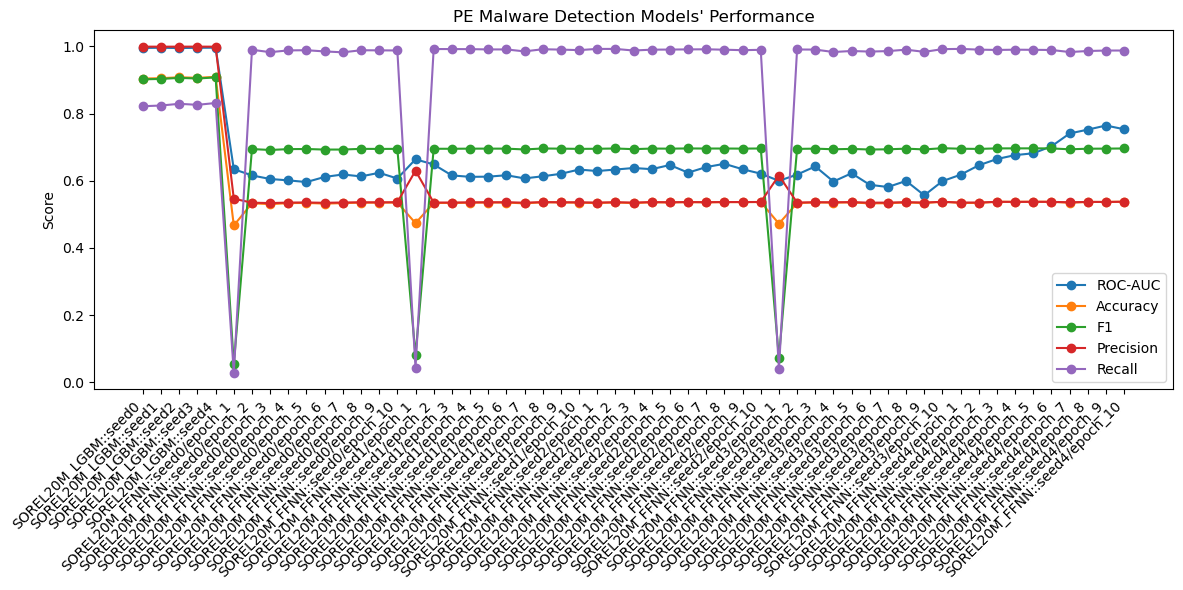

In [7]:
plot_metrics(RESULTS, PLOT_METRICS.ALL)

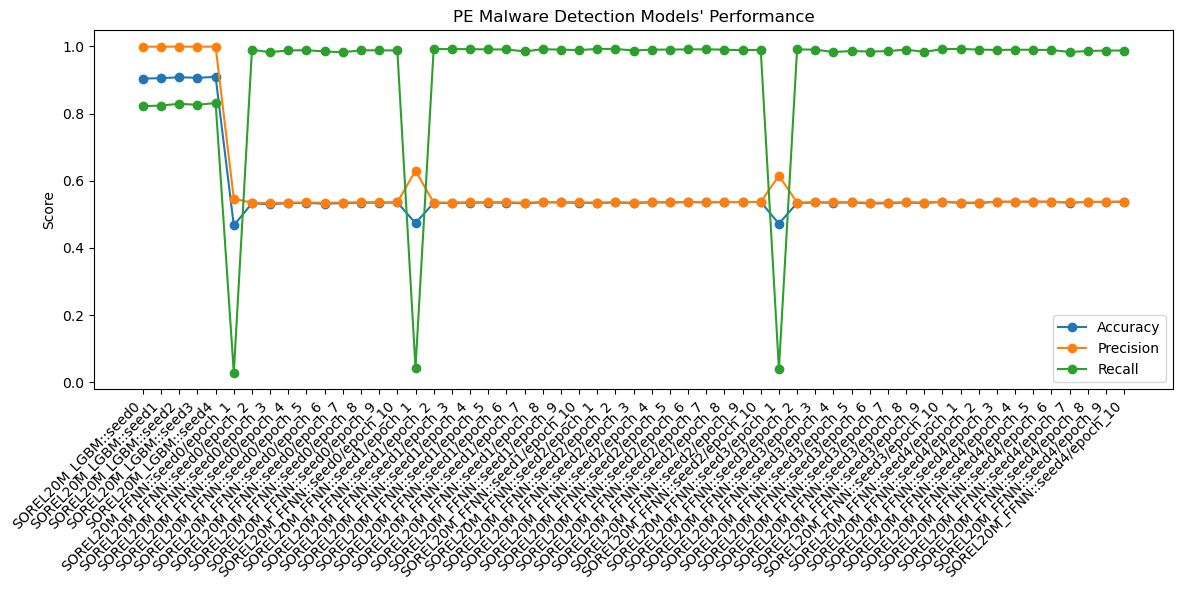

In [8]:
plot_metrics(RESULTS, PLOT_METRICS.ACCURACY | PLOT_METRICS.PRECISION | PLOT_METRICS.RECALL)

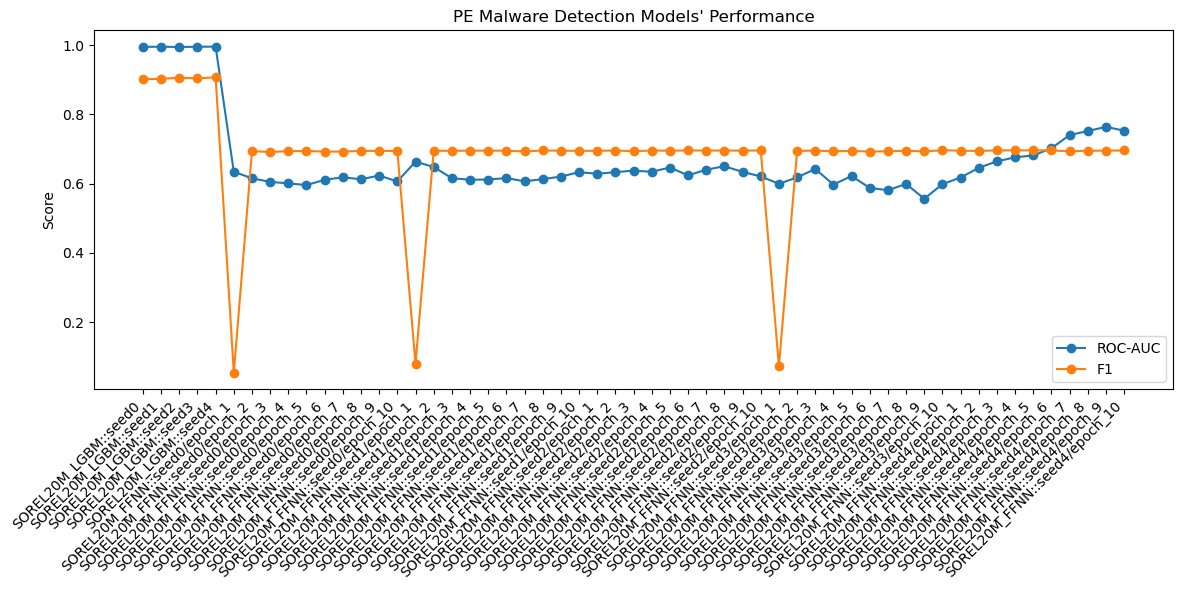

In [9]:
plot_metrics(RESULTS, PLOT_METRICS.F1 | PLOT_METRICS.ROC_AUC)

### c) Displaying pre-rendered ROC, DET curves

In [10]:
display_prerendered_curves(RESULTS)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 308.24it/s]


Accordion(children=(Output(), Output(), Output(), Output(), Output(), Output(), Output(), Output(), Output(), …